In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec
import copy

In [31]:
def plot_final_hero_grid(datasets, master_list):
    # 1. Setup Figure
    fig = plt.figure(figsize=(16, 16)) 
    
    # Grid: 3 rows. 
    # wspace=0.05 keeps columns tight.
    gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.10, wspace=0.03)
    
    # --- AXIS DEFINITIONS ---
    ax_hero = fig.add_subplot(gs[0, 0]) 
    
    row2 = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
    row3 = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2])]
    all_axes = [ax_hero] + row2 + row3
    
    # 2. Colors & Scale
    cmap = copy.copy(plt.get_cmap("viridis"))
    cmap.set_bad(color='#e0e0e0') 
    vmin, vmax = 0.0, 0.9 

    # 3. Create the Index Map
    indices = list(range(len(master_list)))
    
    # 4. Iterate & Plot
    dataset_names = list(datasets.keys())
    
    for idx, ax in enumerate(all_axes):
        if idx >= len(datasets):
            ax.axis('off')
            continue
            
        name = dataset_names[idx]
        df = datasets[name]
        
        # --- DATA PREP ---
        valid_cols = df.columns.intersection(master_list)
        df_clean = df[valid_cols]
        
        if df_clean.empty:
            plot_data = pd.DataFrame(np.nan, index=master_list, columns=master_list)
        else:
            co_occurrence = df_clean.T.dot(df_clean)
            counts = np.diag(co_occurrence)
            with np.errstate(divide='ignore', invalid='ignore'):
                cond_prob = co_occurrence.div(counts, axis=0)
            cond_prob = cond_prob.fillna(0)
            plot_data = cond_prob.reindex(index=master_list, columns=master_list)
        
        # --- PLOTTING ---
        mask = np.eye(len(plot_data), dtype=bool)
        
        sns.heatmap(plot_data, ax=ax, mask=mask,
                    cmap=cmap, vmin=vmin, vmax=vmax,
                    cbar=False, annot=False, 
                    square=True, linewidths=0.5, linecolor='white')
        
        # Titles
        if idx == 0:
            ax.set_title(f"{name}", fontsize=12, fontweight='bold', pad=5)
        else:
            ax.set_title(name, fontsize=12, fontweight='bold', pad=5)

        # --- LABELS ---
        ax.set_xticks(np.arange(len(master_list)) + 0.5)
        ax.set_yticks(np.arange(len(master_list)) + 0.5)
        
        if idx in [4, 5, 6]:
            ax.set_xticklabels(indices, rotation=0, fontsize=9)
        else:
            ax.set_xticklabels([]) 
            
        if idx in [0, 1, 4]:
            ax.set_yticklabels(indices, rotation=0, fontsize=9)
        else:
            ax.set_yticklabels([]) 

    # 5. LEGEND & COLORBAR 
    # Adjusted to sit tight together
    
    # A. The Legend Text
    # We construct the string with double newlines for spacing if needed, or stick to single
    legend_str = "Pathology Index:\n\n" + "\n".join([f" {i}: {label}" for i, label in enumerate(master_list)])
    
    # Place Legend: x=0.40 (Right of Hero), y=0.88 (Top aligned)
    fig.text(0.42, 0.90, legend_str, fontsize=16, va='top', ha='left', family='monospace',
             bbox=dict(boxstyle="round,pad=0.8", fc="#f9f9f9", ec="#cccccc", alpha=1.0))

    # B. The Colorbar
    # Coordinates: [left, bottom, width, height]
    # left=0.56 puts it right next to the legend box (assuming legend width ~0.15)
    # bottom=0.48 aligns with the bottom of the legend text (approx)
    # height=0.40 matches the height of the legend text block
    
    cbar_ax = fig.add_axes([0.70, 0.67, 0.02, 0.24])
    fig.colorbar(all_axes[0].collections[0], cax=cbar_ax, label='Probability')
    
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
    plt.savefig("comorbidity_prevalence.png", dpi=300, bbox_inches='tight')
    plt.show()

In [3]:
# Load the data label directory files
chexpert = r"conditional_probability_matrix_chexpert.csv"
mimic = r"conditional_probability_matrix_mimic.csv"
padchest = r"conditional_probability_matrix_padchest.csv"
nih = r"conditional_probability_matrix_nih.csv"
vindr = r"conditional_probability_matrix_vindr.csv"
openi = r"conditional_probability_matrix_openi.csv"
brax = r"conditional_probability_matrix_brax.csv"

chexpert_sheet = pd.read_csv(chexpert)
mimic_sheet = pd.read_csv(mimic)
padchest_sheet = pd.read_csv(padchest)
nih_sheet = pd.read_csv(nih)
vindr_sheet = pd.read_csv(vindr)
openi_sheet = pd.read_csv(openi)
brax_sheet = pd.read_csv(brax)

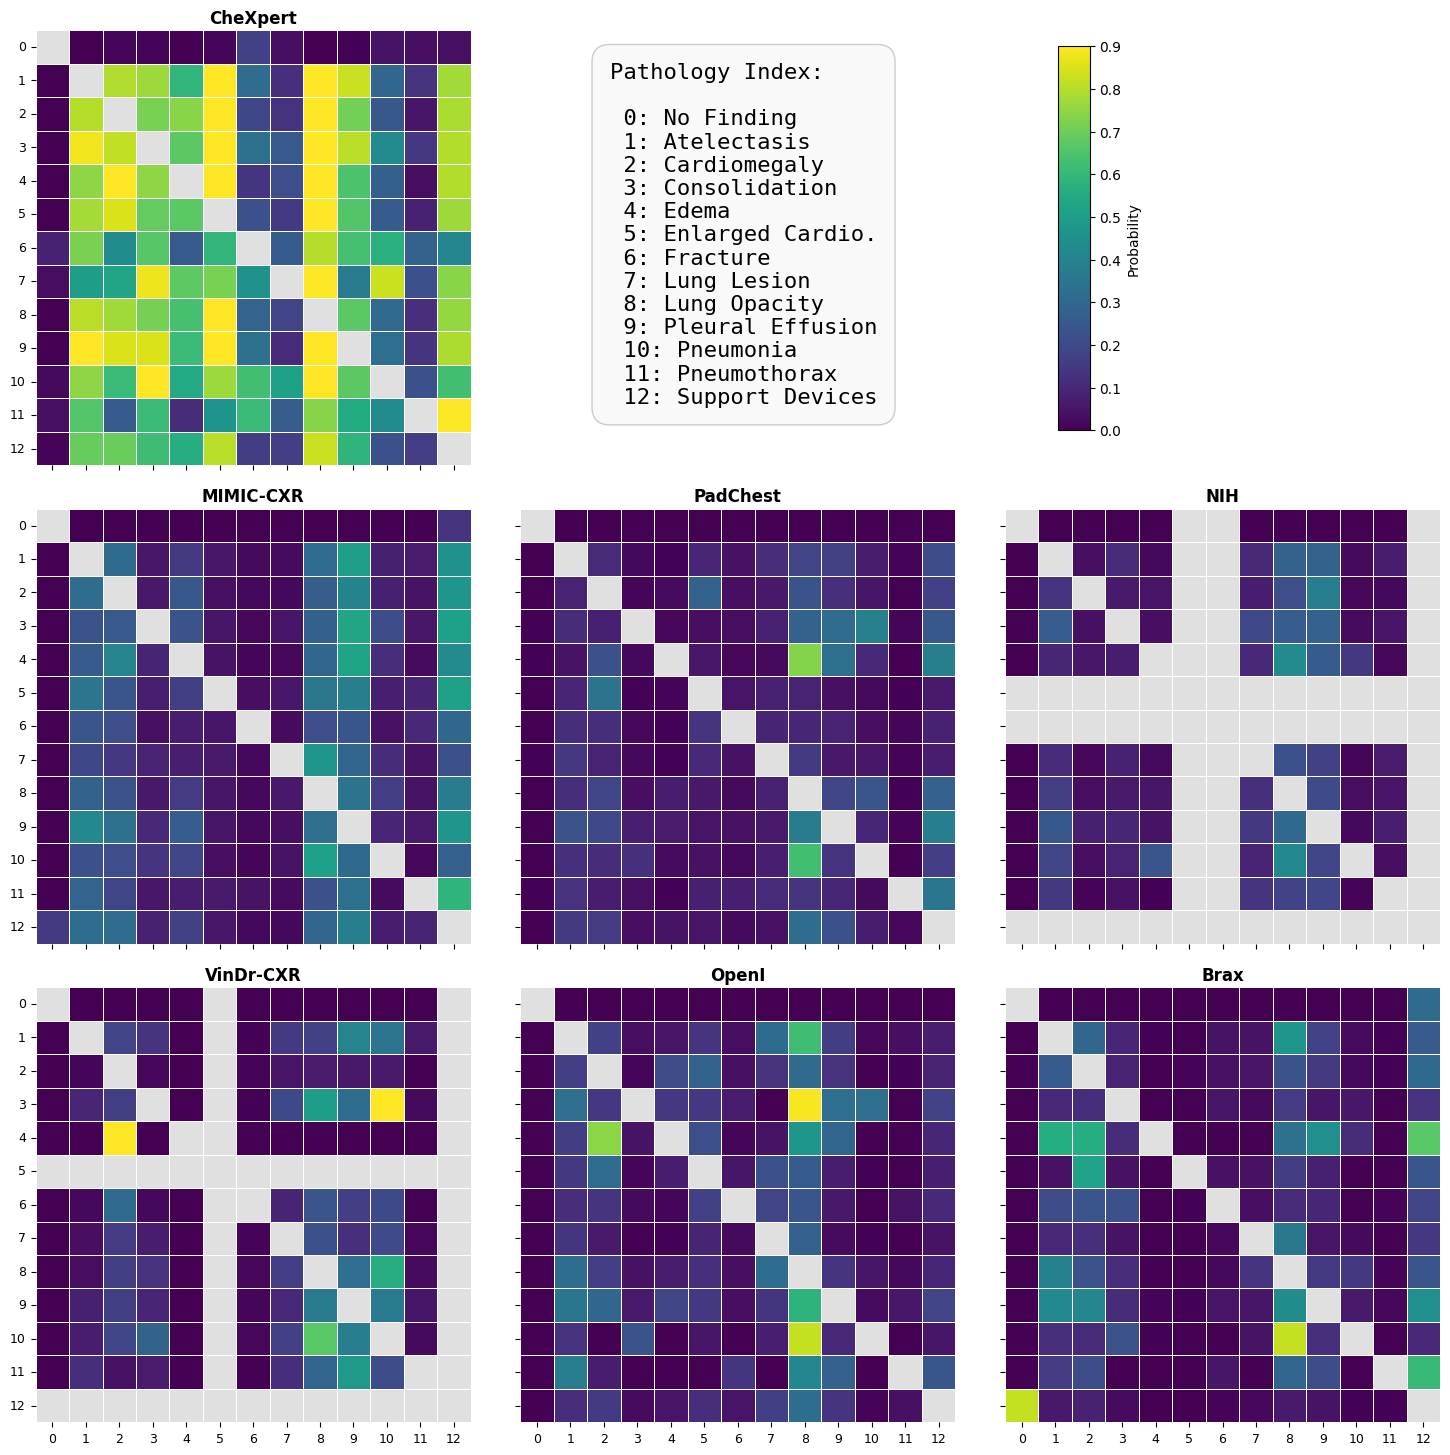

In [32]:
datasets = {
    "CheXpert": chexpert_sheet,
    "MIMIC-CXR": mimic_sheet,
    "PadChest": padchest_sheet,
    "NIH": nih_sheet,
    "VinDr-CXR": vindr_sheet,
    "OpenI": openi_sheet,
    "Brax": brax_sheet
}

master_list = ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardio.', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
plot_final_hero_grid(datasets, master_list)